In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("smartcart_customers.csv")

In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [5]:
df.shape

(2240, 22)

In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [7]:
#  handle missiing values

In [8]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [9]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [10]:
#  feature enginnering

In [11]:
df["Age"] = 2026-df["Year_Birth"]

In [12]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [13]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst = True)
refrence_date = df["Dt_Customer"].max()
df["customer_tenure_days"] = (refrence_date - df["Dt_Customer"]).dt.days

In [14]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [15]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'customer_tenure_days'],
      dtype='object')

In [16]:
df["total_spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] +df["MntSweetProducts"] + df["MntGoldProds"]

In [17]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,total_spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161,422


In [18]:
df["total_child"] = df["Kidhome"] + df["Teenhome"]

In [19]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,total_spending,total_child
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [20]:
df = df.drop("ID",axis = 1)

In [21]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [22]:
df["Education"] = df["Education"].replace({
    "Basic":"undergraduate" , "2n Cycle":"undergraduate",
    "Graduation": "graduate",
    "PhD":"postgraduate","master":"postgraduate"
}
)

In [23]:
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,total_spending,total_child
0,1957,graduate,Single,58138.0,0,0,2012-09-04,58,635,88,...,8,10,4,7,0,1,69,663,1617,0
1,1954,graduate,Single,46344.0,1,1,2014-03-08,38,11,1,...,1,1,2,5,0,0,72,113,27,2
2,1965,graduate,Together,71613.0,0,0,2013-08-21,26,426,49,...,8,2,10,4,0,0,61,312,776,0
3,1984,graduate,Together,26646.0,1,0,2014-02-10,26,11,4,...,2,0,4,6,0,0,42,139,53,1
4,1981,postgraduate,Married,58293.0,1,0,2014-01-19,94,173,43,...,5,3,6,5,0,0,45,161,422,1


In [24]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [25]:
df["living_with"] = df["Marital_Status"].replace({
    "Married":"partner","Together":"partner",
    "Single":"single","Divorced":"single","Widow":"single","Alone":"single",
    "Absurd":"single","YOLO":"single"
})

In [26]:
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,total_spending,total_child,living_with
0,1957,graduate,Single,58138.0,0,0,2012-09-04,58,635,88,...,10,4,7,0,1,69,663,1617,0,single
1,1954,graduate,Single,46344.0,1,1,2014-03-08,38,11,1,...,1,2,5,0,0,72,113,27,2,single
2,1965,graduate,Together,71613.0,0,0,2013-08-21,26,426,49,...,2,10,4,0,0,61,312,776,0,partner
3,1984,graduate,Together,26646.0,1,0,2014-02-10,26,11,4,...,0,4,6,0,0,42,139,53,1,partner
4,1981,postgraduate,Married,58293.0,1,0,2014-01-19,94,173,43,...,3,6,5,0,0,45,161,422,1,partner


In [27]:
df.columns

Index(['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'customer_tenure_days', 'total_spending',
       'total_child', 'living_with'],
      dtype='object')

In [28]:
cols = ["Year_Birth","Kidhome","Teenhome","Dt_Customer","MntWines","MntFruits","Marital_Status","MntMeatProducts",
       "MntFishProducts","MntSweetProducts","MntGoldProds"]

In [29]:
df = df.drop(columns = df[cols] , axis = 1)

In [30]:
df.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,total_spending,total_child,living_with
0,graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,single
1,graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,single
2,graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,partner
3,graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,partner
4,postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,partner


In [31]:
#  outliers

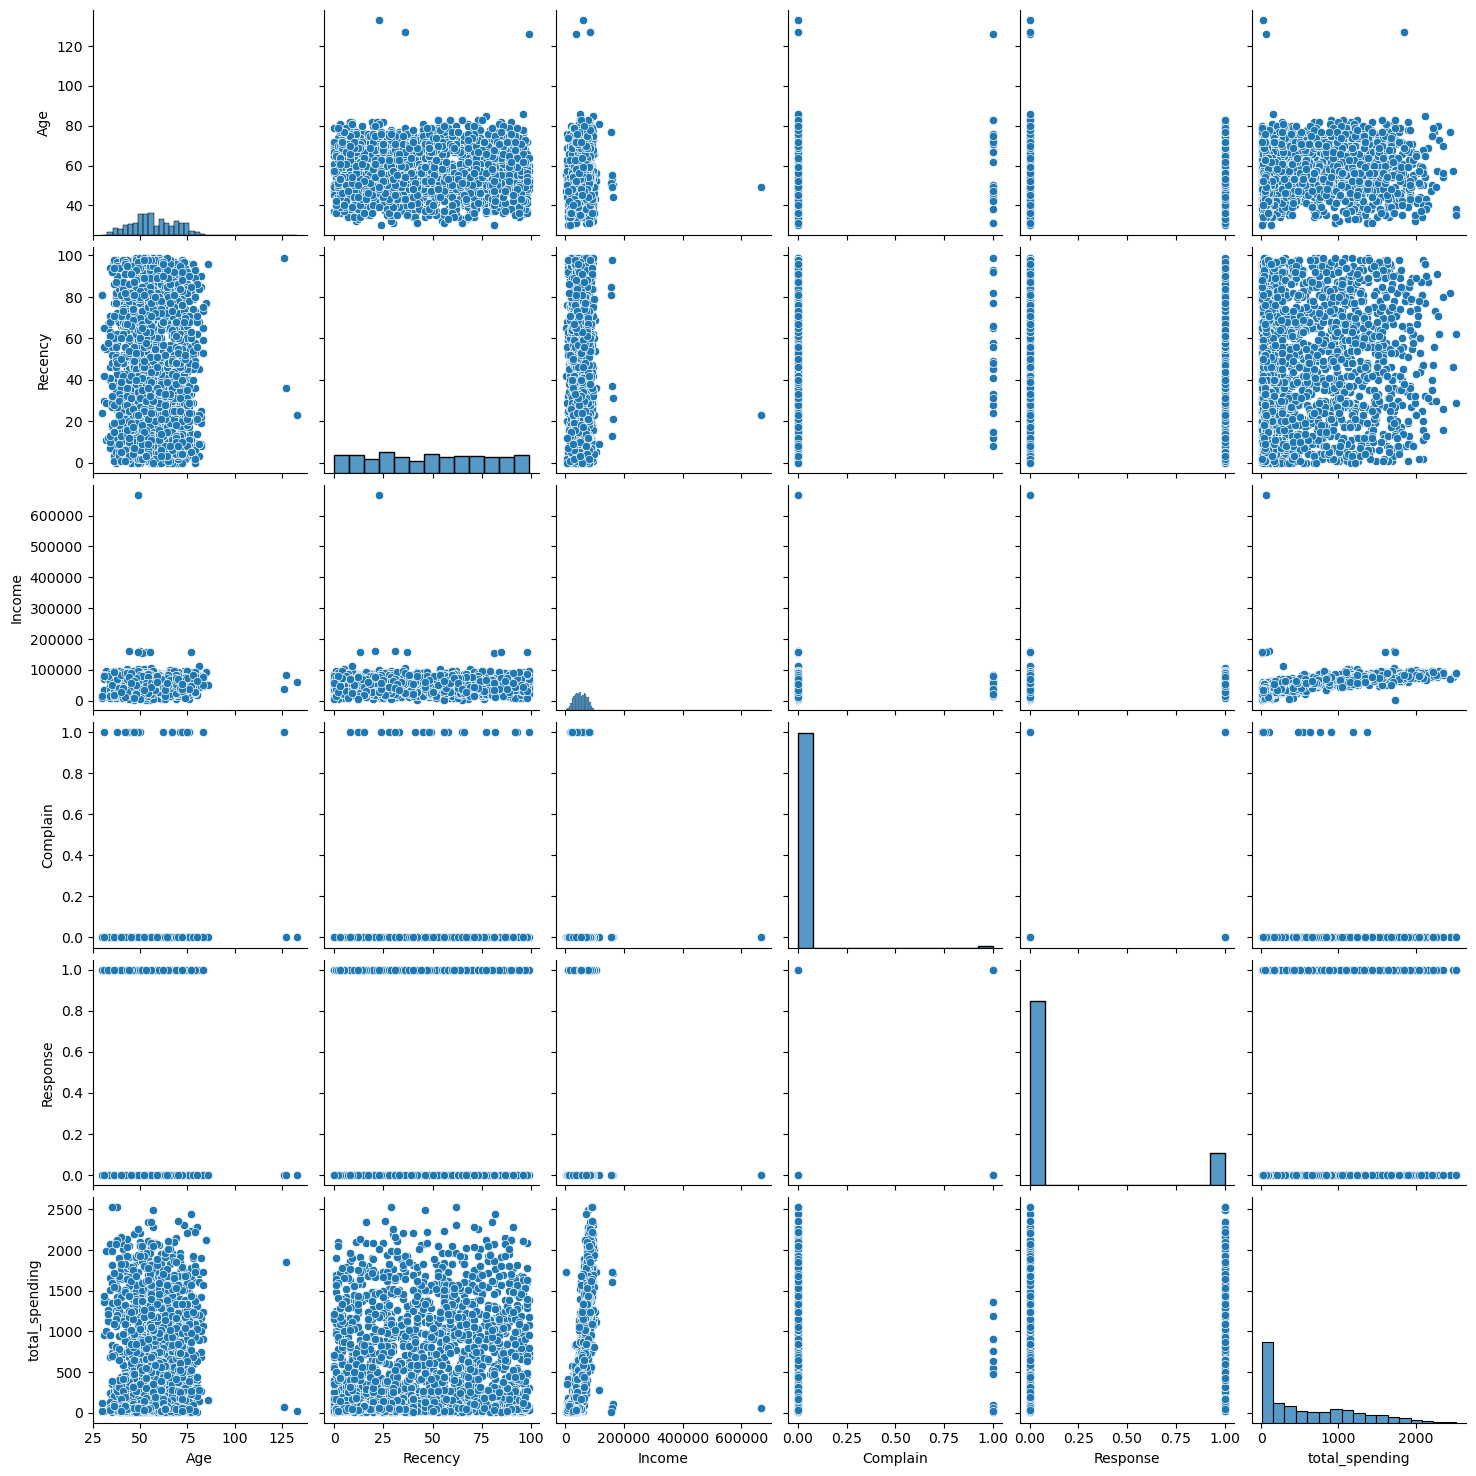

In [32]:
cols = ["Education","Age","Recency","Income","Complain","Response","total_spending"]

sns.pairplot(df[cols])

In [33]:
print("data size with outliers" , len(df))

data size with outliers 2240


In [34]:
df = df[(df["Age"]<90)]
df = df[(df["Income"]<600_000)]

print("size after outliers: ",len(df))

size after outliers:  2236


In [35]:
# correletion heatmaps

In [36]:
corr = df.corr(numeric_only = True)

<Axes: >

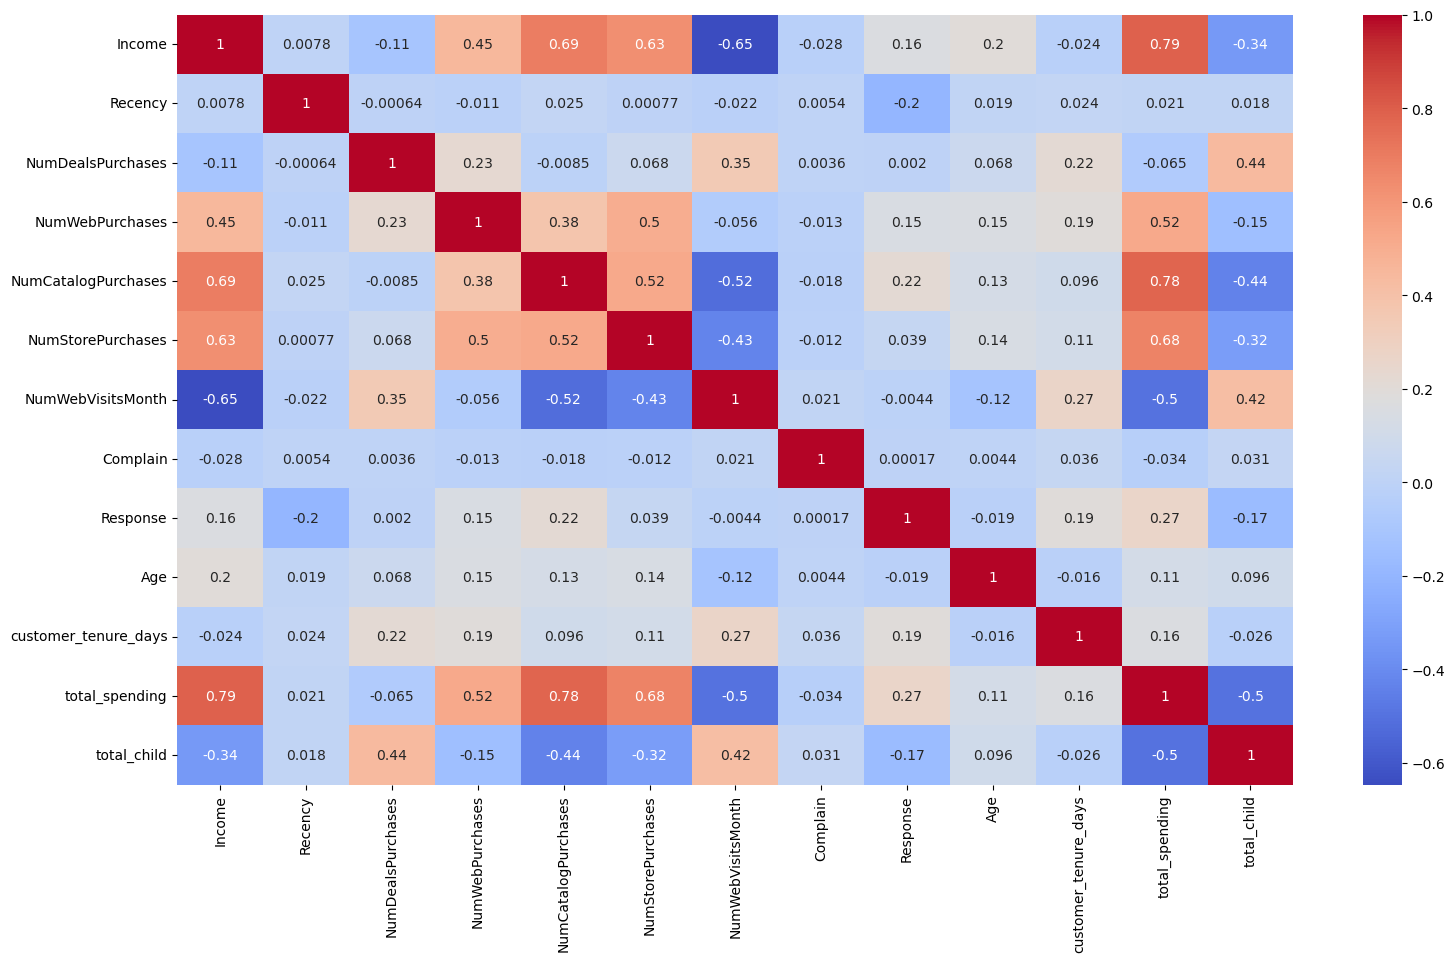

In [37]:
plt.figure(figsize = (18,10))

sns.heatmap(
    corr,
    annot =True,
    cmap = "coolwarm"
)

In [38]:
df.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,total_spending,total_child,living_with
0,graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,single
1,graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,single
2,graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,partner
3,graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,partner
4,postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,partner


In [39]:
from sklearn.preprocessing import OneHotEncoder

In [40]:
one = OneHotEncoder()

In [41]:
col = ["Education","living_with"]

In [42]:
encoded = one.fit_transform(df[col])

In [43]:
encoded_df = pd.DataFrame(encoded.toarray(),columns = one.get_feature_names_out(col),index = df.index)

In [44]:
df = pd.concat([df.drop(columns = col),encoded_df],axis = 1)

In [45]:
df.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,total_spending,total_child,Education_Master,Education_graduate,Education_postgraduate,Education_undergraduate,living_with_partner,living_with_single
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,0.0,1.0,0.0,0.0,0.0,1.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,0.0,1.0,0.0,0.0,0.0,1.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,0.0,1.0,0.0,0.0,1.0,0.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,0.0,1.0,0.0,0.0,1.0,0.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,0.0,1.0,0.0,1.0,0.0


In [46]:
df.shape

(2236, 19)

In [47]:
from sklearn.preprocessing import StandardScaler

In [48]:
scaler = StandardScaler()

In [49]:
x = df

x_scaled = scaler.fit_transform(x)

In [50]:
# 2d

from sklearn.decomposition import PCA

In [51]:
pca = PCA(n_components = 3)

In [52]:
x_pca = pca.fit_transform(x_scaled)

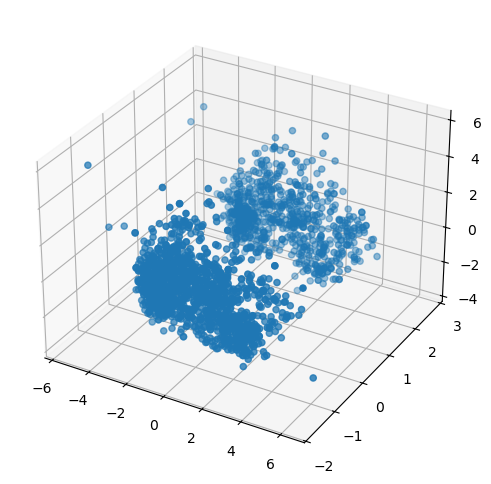

In [53]:
fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111,projection ="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])

In [54]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

In [55]:
wcss = []
for k in range(1,11):
    model = KMeans(n_clusters = k,random_state = 42)
    labels = model.fit_predict(x_pca)
    wcss.append(model.inertia_)

In [56]:
knee = KneeLocator(range(1,11),wcss,curve = "convex",direction = "decreasing")
optimal_k = knee.elbow

In [57]:
print(optimal_k)

4


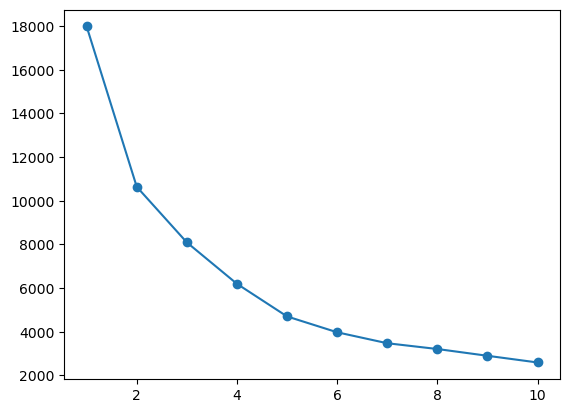

In [58]:
plt.plot(range(1,11),wcss,marker = "o")

In [59]:
#  sihoutte scoer

In [60]:
from sklearn.metrics import silhouette_score

<Axes: >

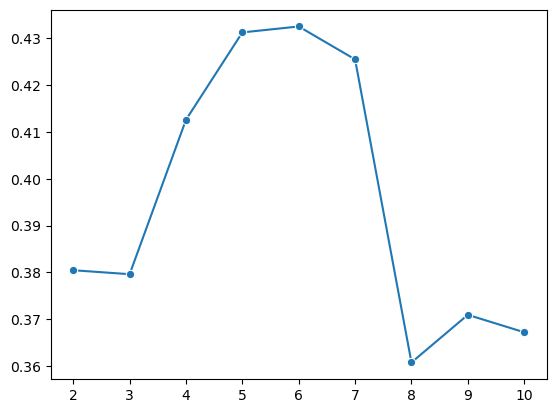

In [61]:
ss = []
for k in range(2,11):
    model = KMeans(n_clusters = k,random_state = 42)
    labels = model.fit_predict(x_pca)
    ss.append(silhouette_score(x_pca , labels))
sns.lineplot(x = range(2,11),y = ss,marker = "o")

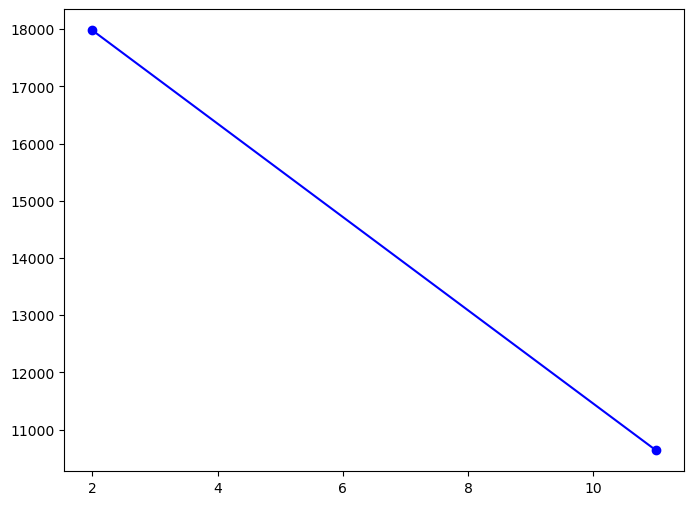

In [62]:
k_range = (2,11)

fig,ax1 = plt.subplots(figsize = (8,6))
ax1.plot(k_range , wcss[:len(k_range)],marker = "o",color = "blue")


In [63]:
model = KMeans(n_clusters = 4,random_state = 42)
labels = model.fit_predict(x_pca)


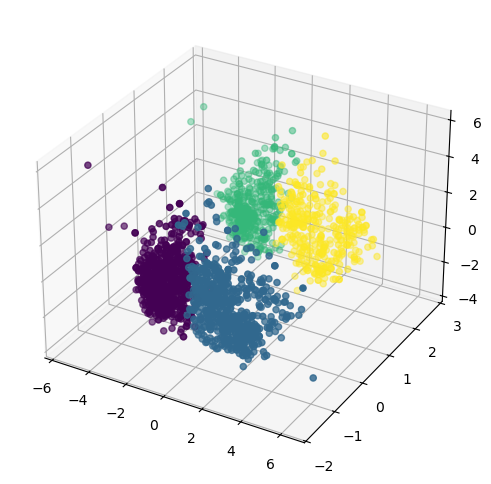

In [64]:
fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111,projection ="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c =labels)

In [65]:
from sklearn.cluster import AgglomerativeClustering

In [66]:
agg = AgglomerativeClustering(n_clusters = 4,linkage = "ward")

In [67]:
labels_agg = agg.fit_predict(x_pca)

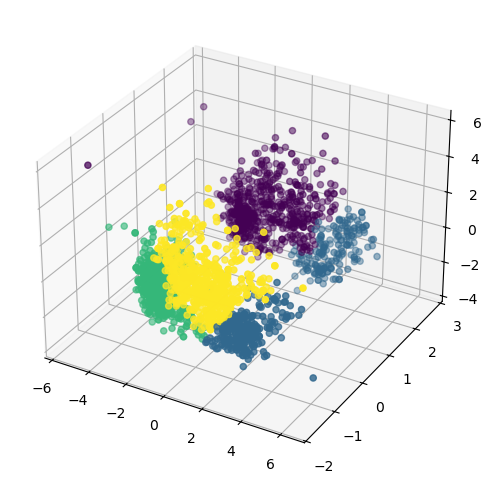

In [68]:
fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111,projection ="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c =labels_agg)

In [69]:
#  chrectersisation 
x["cluster"] = labels_agg

In [70]:
x.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,total_spending,total_child,Education_Master,Education_graduate,Education_postgraduate,Education_undergraduate,living_with_partner,living_with_single,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,0.0,1.0,0.0,0.0,0.0,1.0,0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,0.0,1.0,0.0,0.0,0.0,1.0,0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,0.0,1.0,0.0,0.0,1.0,0.0,3
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,0.0,1.0,0.0,0.0,1.0,0.0,2
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,0.0,1.0,0.0,1.0,0.0,3


<Axes: xlabel='cluster', ylabel='count'>

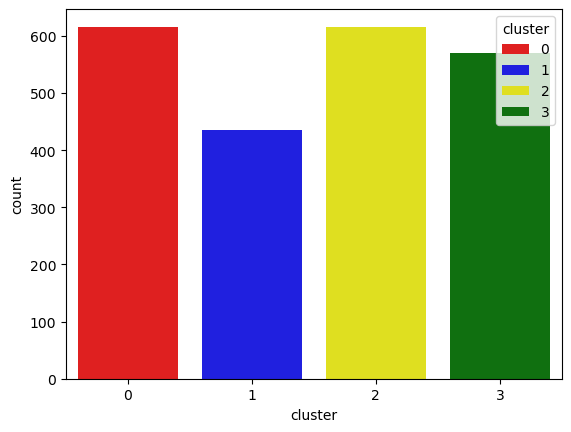

In [71]:
pal = ["red","blue","yellow","green"]
sns.countplot(x = x["cluster"],palette = pal , hue = x["cluster"])

<Axes: xlabel='total_spending', ylabel='Income'>

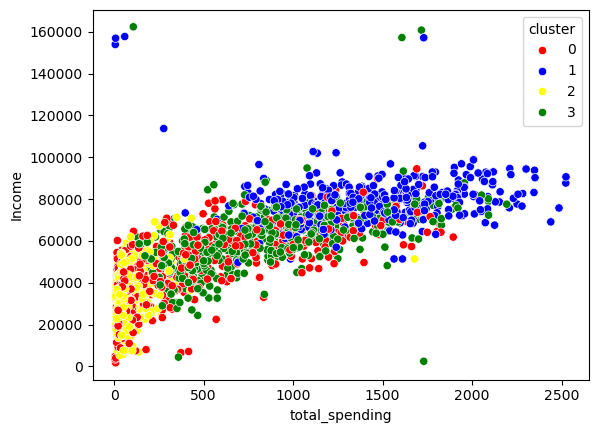

In [72]:
sns.scatterplot(x = x["total_spending"],y = x["Income"],hue=x["cluster"],palette = pal)

In [74]:
cluster_summary = x.groupby("cluster").mean()

In [75]:
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        44268.955357  47.987013           2.655844         3.892857   
1        78763.178161  51.204598           0.967816         4.705747   
2        33711.121951  49.100813           1.865041         1.920325   
3        59477.273684  48.759649           3.503509         6.164912   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   1.740260           4.975649           6.232143  0.009740   
1                   6.193103           8.471264           2.133333  0.004598   
2                   0.469919           3.156098           6.416260  0.011382   
3                   3.333333           7.487719           5.578947  0.008772   

         Response        Age  customer_tenure_days  total_spending  \
cluster         